In [1]:
%load_ext autoreload

%autoreload 2

In [3]:
import pandas as pd
import math
from datetime import datetime, timedelta
from difflib import SequenceMatcher
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
import warnings
from Preproces_prod import *
warnings.filterwarnings("ignore")


In [98]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [99]:
df_urba_rural = pd.read_excel(path_data/'urba_rural.xlsx')

In [100]:
poblacion_agrupada = (
    df_urba_rural
    .groupby(['Comuna', 'Area (1=Urbano 2=Rural)'])['Poblacion 2024'].sum().reset_index()
    .rename(columns={'Poblacion 2024': 'Total Poblacion'})
)


poblacion_total_comuna = (
    poblacion_agrupada
    .groupby('Comuna')['Total Poblacion'].sum().reset_index()
    .rename(columns={'Total Poblacion': 'Poblacion Total Comuna'})
)


df_urba_rural_percent = (
    poblacion_agrupada
    .merge(poblacion_total_comuna, on='Comuna')
    .assign(Porcentaje=lambda x: (x['Total Poblacion'] / x['Poblacion Total Comuna']))
    .pivot(index='Comuna', columns='Area (1=Urbano 2=Rural)', values='Porcentaje')
    .rename(columns={1: 'Porcentaje Urbano', 2: 'Porcentaje Rural'})  # Renombra las columnas correspondientes
    .reset_index()
    .pipe(lambda df: df.rename_axis(None, axis=1))
)


df_urba_rural_percent

,Comuna,Porcentaje Urbano,Porcentaje Rural
0,1101,0.983053,0.016947
1,1107,0.978387,0.021613
2,1401,0.664618,0.335382
3,1402,0.000000,1.000000
4,1403,0.000000,1.000000
...,...,...,...
341,16301,0.648692,0.351308
342,16302,0.363883,0.636117
343,16303,0.103592,0.896408
344,16304,0.367619,0.632381


In [101]:
df = pre_filtred('NAC_RNI_EGRESOS_ENTREGA_ISCI_04_09_2024_encr.csv')
df_f = filtros_IH(df)
dfs = cortes(df_f)


Datos perdidos por filtro peso:  875
Datos perdidos por filtro semanas y peso:  1374
Datos perdidos por fecha ingreso menor a fecha nacimiento: 0


In [102]:
df_copy = df.copy()
df_f_copy = df_f.copy()

## Consultas

In [ ]:
#df['age_vrs'] = (df['FECHA_ING'] - df['FECHA_NAC']).dt.days
#print(df_vrs['age_vrs'].mean())

In [9]:
# Filtrar los datos
inmunes = df['days_estad_vrs'][(df['inmunizado'] == 1) & (df['days_estad_vrs'] > 0)]
no_inmunes = df['days_estad_vrs'][(df['inmunizado'] == 0) & (df['days_estad_vrs'] > 0)]

# Calcular las medias y tamaños de muestra
media_inmunes = inmunes.mean()
media_no_inmunes = no_inmunes.mean()
n_inmunes = inmunes.count()
n_no_inmunes = no_inmunes.count()

# Calcular la prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(inmunes, no_inmunes)

# Mostrar las medias y tamaños de muestra
print(f"Media (Inmunizados): {media_inmunes:.2f} (N = {n_inmunes})")
print(f"Media (No inmunizados): {media_no_inmunes:.2f} (N = {n_no_inmunes})")

# Mostrar los resultados de la prueba t
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")


Media (Inmunizados): 3.13 (N = 121)
Media (No inmunizados): 4.31 (N = 131)
Estadístico t: -3.2249
Valor p: 0.0014
Existe una diferencia significativa entre las medias de los dos grupos.


In [15]:
df.query('days_estad_vrs>0').groupby(['inmunizado']).days_estad_vrs.mean()

inmunizado
0    4.312977
1    3.132231
Name: days_estad_vrs, dtype: float64

In [16]:
df.query('days_upc_vrs>0').groupby(['inmunizado']).days_upc_vrs.mean()

inmunizado
0    6.562500
1    5.833333
Name: days_upc_vrs, dtype: float64

In [19]:
df['age_vrs'] = ((df['FECHA_ING'] - df['FECHA_NAC']).dt.days/30)

In [22]:
df.query('days_estad_vrs>0').groupby(['inmunizado']).age_vrs.mean()

inmunizado
0    3.411705
1    2.517906
Name: age_vrs, dtype: float64

In [23]:
df.query('days_upc_vrs>0').groupby(['inmunizado']).age_vrs.mean()

inmunizado
0    4.15
1    3.45
Name: age_vrs, dtype: float64

In [36]:
grupo_2019 = pd.read_csv(path_data/'grupo_2019.csv')
grupo_2019=grupo_2019['days_upc_vrs']

grupo_2023 = pd.read_csv(path_data/'grupo_2023.csv')
grupo_2023=grupo_2023['days_upc_vrs']

grupo_noIn = df.query('days_upc_vrs>0')[df['inmunizado'] == 0]['days_upc_vrs']

In [37]:
# Realizar el test t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_2019, grupo_noIn)

print("TEST ESTADÍSTICO NO INMUNE VS 2019\n")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

# Realizar el test t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_2023, grupo_noIn)

print("\nTEST ESTADÍSTICO NO INMUNE VS 2023\n")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

TEST ESTADÍSTICO NO INMUNE VS 2019

Estadístico t: 0.1107
Valor p: 0.9119
No existe una diferencia significativa entre las medias de los dos grupos.

TEST ESTADÍSTICO NO INMUNE VS 2023

Estadístico t: 0.3387
Valor p: 0.7348
No existe una diferencia significativa entre las medias de los dos grupos.


In [ ]:
# Definir los dos grupos
grupo_2019 = df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD')[df['elegibilidad'] == valor_grupo_1]['DIAS_ESTAD']
grupo_noIn = df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD')[df['elegibilidad'] == valor_grupo_2]['DIAS_ESTAD']

# Realizar el test t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_2019, grupo_noIn)

# Mostrar los resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

In [6]:
inmunes = df['days_estad_vrs'][(df['inmunizado']==1) & (df['days_estad_vrs']>0)]
no_inmunes = df['days_estad_vrs'][(df['inmunizado']==0) & (df['days_estad_vrs']>0)]

# Calcular la prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(inmunes, no_inmunes)

# Mostrar los resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

Estadístico t: -3.2249
Valor p: 0.0014
Existe una diferencia significativa entre las medias de los dos grupos.


In [8]:
# Filtrar los datos
inmunes = df['days_upc_vrs'][(df['inmunizado'] == 1) & (df['days_upc_vrs'] > 0)]
no_inmunes = df['days_upc_vrs'][(df['inmunizado'] == 0) & (df['days_upc_vrs'] > 0)]

# Calcular las medias y tamaños de muestra
media_inmunes = inmunes.mean()
media_no_inmunes = no_inmunes.mean()
n_inmunes = inmunes.count()
n_no_inmunes = no_inmunes.count()

# Calcular la prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(inmunes, no_inmunes)

# Mostrar las medias y tamaños de muestra
print(f"Media (Inmunizados): {media_inmunes:.2f} (N = {n_inmunes})")
print(f"Media (No inmunizados): {media_no_inmunes:.2f} (N = {n_no_inmunes})")

# Mostrar los resultados de la prueba t
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

Media (Inmunizados): 5.83 (N = 6)
Media (No inmunizados): 6.56 (N = 16)
Estadístico t: -0.3230
Valor p: 0.7501
No existe una diferencia significativa entre las medias de los dos grupos.


In [21]:
df_vrs[df_vrs['group']=='CATCH_UP']['age_vrs'].mean()

105.48255813953489

In [23]:
df_vrs[df_vrs['group']=='SEASONAL']['age_vrs'].mean()

38.9622641509434

In [19]:
df_vrs['age_vrs'].describe()

count    225.000000
mean      89.813333
std       55.927894
min        7.000000
25%       47.000000
50%       69.000000
75%      129.000000
max      249.000000
Name: age_vrs, dtype: float64

## Modelos IH

### Preprocesamiento

In [103]:
df_tilWeek=dfs[25]

In [105]:
df_0, base, df_model, covs = preprocess_model_IH(df_tilWeek)

In [106]:
split_df(df_tilWeek, 'Macrozona2')
print("\n")
split_df(df_tilWeek, 'NOMBRE_REGION')


Hay 3 valores únicos en Macrozona2
Hay 3 N/A en Macrozona2
Variable df_UW_Centro creada con 88420 filas y guardada en ..\Data\Macrozona2\df_UW_Centro.csv
Variable df_UW_Norte creada con 11977 filas y guardada en ..\Data\Macrozona2\df_UW_Norte.csv
Variable df_UW_Sur creada con 16009 filas y guardada en ..\Data\Macrozona2\df_UW_Sur.csv
Hay un valor N/A como unique, saltando este valor.


Hay 15 valores únicos en NOMBRE_REGION
Hay 3 N/A en NOMBRE_REGION
Variable df_UW_METROPOLITANA creada con 46088 filas y guardada en ..\Data\NOMBRE_REGION\df_UW_METROPOLITANA.csv
Variable df_UW_O'HIGGINS creada con 6247 filas y guardada en ..\Data\NOMBRE_REGION\df_UW_O'HIGGINS.csv
Variable df_UW_MAULE creada con 7130 filas y guardada en ..\Data\NOMBRE_REGION\df_UW_MAULE.csv
Variable df_UW_BIOBIO creada con 9766 filas y guardada en ..\Data\NOMBRE_REGION\df_UW_BIOBIO.csv
Variable df_UW_NUBLE creada con 3110 filas y guardada en ..\Data\NOMBRE_REGION\df_UW_NUBLE.csv
Variable df_UW_ANTOFAGASTA creada con 4704 

In [13]:
pd.set_option('display.max_colwidth', None)

In [16]:
df_0.query('RUN=="0388d11eaaba768c88b1414fff1a4b999b6dc358caef85c6c87666150876d64f"')

,start,inmunizado,stop,RUN,event
1772,8.0,0,9.0,0388d11eaaba768c88b1414fff1a4b999b6dc358caef85c6c87666150876d64f,False
1773,9.0,True,64.0,0388d11eaaba768c88b1414fff1a4b999b6dc358caef85c6c87666150876d64f,True


In [ ]:
df_model[df_model['duration']== df_model.duration.max()]

In [ ]:
base[base['duration']== base.duration.max()]

### Modelo_0

Iteration 1: norm_delta = 4.57e-01, step_size = 0.9500, log_lik = -2912.16008, newton_decrement = 2.02e+01, seconds_since_start = 0.5
Iteration 2: norm_delta = 2.20e-02, step_size = 0.9500, log_lik = -2893.50295, newton_decrement = 5.58e-02, seconds_since_start = 0.9
Iteration 3: norm_delta = 1.13e-03, step_size = 0.9500, log_lik = -2893.44729, newton_decrement = 1.46e-04, seconds_since_start = 1.4
Iteration 4: norm_delta = 5.96e-05, step_size = 1.0000, log_lik = -2893.44715, newton_decrement = 3.67e-07, seconds_since_start = 1.8
Iteration 5: norm_delta = 2.37e-10, step_size = 1.0000, log_lik = -2893.44715, newton_decrement = 5.82e-18, seconds_since_start = 2.2
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 204046 periods, 116409 subjects, 253 events>
         event col = 'event'
number of subjects = 116409
 number of periods = 204046
  number of events = 253
partial log-likelihood = -2893.45
  time fit was run = 2024-09-16 17:36:49 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -0.87      0.42      0.14           -1.14           -0.60                0.32                0.55

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -6.24 <0.005     31.05
---
Partial AIC = 5788.89
log-likelihood ratio test = 37.43 on 1 df
-log2(p) of ll-ratio test = 29.97

covariate
inmunizado    0.580566
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado           0.6808         0.448856


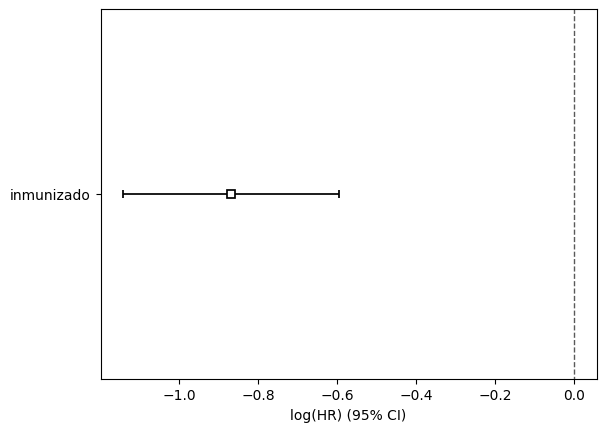

In [107]:
cox_model(df_0)

#### Modelo_0 + covariables fijas 

In [ ]:
d=df_0.merge(covs[1], on='RUN',how='left') 
cox_model(d)

### Modelo_3m

In [108]:
df_01 = cov_Mmeses(df_0, base, df_model, 3)

Iteration 1: norm_delta = 6.75e-01, step_size = 0.9500, log_lik = -2912.16008, newton_decrement = 4.62e+01, seconds_since_start = 0.8
Iteration 2: norm_delta = 2.33e-02, step_size = 0.9500, log_lik = -2867.97430, newton_decrement = 7.32e-02, seconds_since_start = 1.5
Iteration 3: norm_delta = 1.21e-03, step_size = 0.9500, log_lik = -2867.90115, newton_decrement = 1.99e-04, seconds_since_start = 2.3
Iteration 4: norm_delta = 6.41e-05, step_size = 1.0000, log_lik = -2867.90096, newton_decrement = 4.99e-07, seconds_since_start = 3.1
Iteration 5: norm_delta = 4.40e-10, step_size = 1.0000, log_lik = -2867.90096, newton_decrement = 2.45e-17, seconds_since_start = 3.9
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 237234 periods, 116409 subjects, 253 events>
         event col = 'event'
number of subjects = 116409
 number of periods = 237234
  number of events = 253
partial log-likelihood = -2867.90
  time fit was run = 2024-09-16 17:42:19 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -0.98      0.38      0.14           -1.26           -0.71                0.28                0.49
si_3_meses -0.92      0.40      0.13           -1.17           -0.66                0.31                0.52

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -7.00 <0.005     38.49
si_3_meses    0.00 -7.04 <0.005     38.96
---
Partial AIC = 5739.80
log-likelihood ratio test = 88.52 on 2 df
-log2(p) of ll-ratio test = 63.85

covariate
inmunizado    0.624985
si_3_meses    0.599537
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.715059         0.506436
si_3_meses         0.689560         0.483409


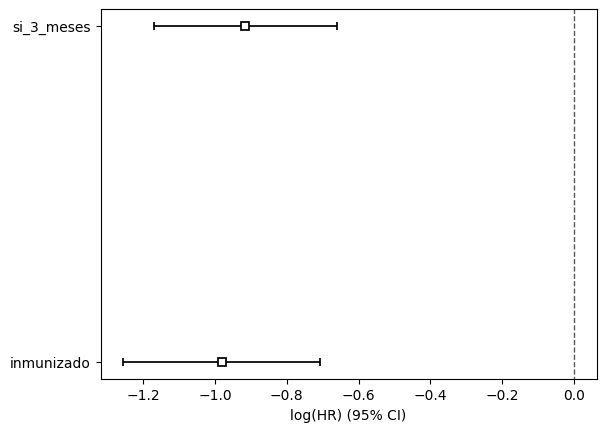

In [109]:
cox_model(df_01)

#### Modelo_3m + covariables fijas

In [ ]:
for i in [covs[1]]:
    d=df_01.merge(i, on='RUN',how='left') 
    cox_model(d)

#### Strata Análisis

In [110]:
d=df_01.merge(covs[0], on='RUN',how='left') 
#d['categori_macro'] = d['Macrozona2'].astype('category').cat.codes + 1
#d['categori_regions'] = d['NOMBRE_REGION'].astype('category').cat.codes + 1

In [ ]:
d['categori_macro'].value_counts()

In [ ]:
d['INS_C_M'].value_counts()

In [113]:
#df_urba_rural_percent=df_urba_rural_percent.rename(columns={'Comuna':'COMUNA' , 'Porcentaje Rural':'porcent_rural'})
#d=d.merge(df_urba_rural_percent, on='COMUNA', how='left')

Iteration 1: norm_delta = 7.62e-01, step_size = 0.9500, log_lik = -2771.19351, newton_decrement = 6.06e+01, seconds_since_start = 0.8
Iteration 2: norm_delta = 7.17e-02, step_size = 0.9500, log_lik = -2719.10792, newton_decrement = 3.28e+00, seconds_since_start = 1.6
Iteration 3: norm_delta = 2.47e-02, step_size = 0.9500, log_lik = -2715.44767, newton_decrement = 2.91e-01, seconds_since_start = 2.3
Iteration 4: norm_delta = 4.21e-03, step_size = 1.0000, log_lik = -2715.14144, newton_decrement = 6.36e-03, seconds_since_start = 3.1
Iteration 5: norm_delta = 7.06e-05, step_size = 1.0000, log_lik = -2715.13501, newton_decrement = 1.73e-06, seconds_since_start = 3.8
Iteration 6: norm_delta = 1.95e-08, step_size = 1.0000, log_lik = -2715.13501, newton_decrement = 1.32e-13, seconds_since_start = 4.6
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 237234 periods, 116409 subjects, 253 events>
         event col = 'event'
            strata = Macrozona2
number of subjects = 116409
 number of periods = 237234
  number of events = 253
partial log-likelihood = -2715.14
  time fit was run = 2024-09-17 14:41:03 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -1.03      0.36      0.14           -1.30           -0.75                0.27                0.47
si_3_meses    -0.92      0.40      0.13           -1.17           -0.66                0.31                0.52
SEXO           0.43      1.54      0.13            0.18            0.68                1.19                1.98
muy_prematuro  1.09      2.98      0.32            0.46            1.73                1.58                5.62

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -7.29 <0.005     41.60
si_3_meses       0.00 -7.06 <0.005     39.08
SEXO             0.00  3.33 <0.005     10.19
muy_prematuro    0.00  3.38 <0.005     10.45
---
Partial AIC = 5438.27
log-likelihood ratio test = 112.12 on 4 df
-log2(p) of ll-ratio test = 75.04

covariate
inmunizado       0.642083
si_3_meses       0.599957
SEXO            -0.537657
muy_prematuro   -1.982148
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.728425         0.528291
si_3_meses            0.689849         0.484013
SEXO                 -0.193943        -0.980321
muy_prematuro        -0.583588        -4.615859


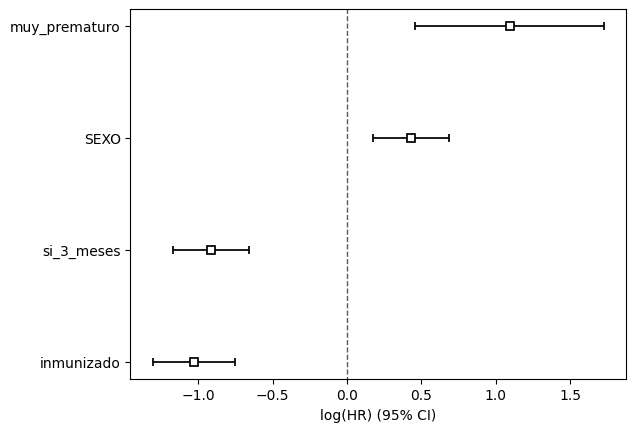

In [198]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(d[['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO', 'muy_prematuro', 'Macrozona2']], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop",strata=['Macrozona2'], show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

In [ ]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(d[['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO', 'muy_prematuro','group']], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop",strata=['group'], show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

In [ ]:
d.porcent_rural.isna().sum()
#d=d[~d.porcent_rural.isna()]
#d['is_rural'] = np.where(d.porcent_rural>0.5,1,0)
#d['exp_rural'] = np.exp(d['porcent_rural'])

Iteration 1: norm_delta = 7.58e-01, step_size = 0.9500, log_lik = -2398.34092, newton_decrement = 6.00e+01, seconds_since_start = 0.7
Iteration 2: norm_delta = 7.18e-02, step_size = 0.9500, log_lik = -2346.89028, newton_decrement = 3.36e+00, seconds_since_start = 1.3
Iteration 3: norm_delta = 2.51e-02, step_size = 0.9500, log_lik = -2343.13969, newton_decrement = 3.02e-01, seconds_since_start = 1.8
Iteration 4: norm_delta = 4.33e-03, step_size = 1.0000, log_lik = -2342.82149, newton_decrement = 6.73e-03, seconds_since_start = 2.3
Iteration 5: norm_delta = 7.47e-05, step_size = 1.0000, log_lik = -2342.81468, newton_decrement = 1.93e-06, seconds_since_start = 2.8
Iteration 6: norm_delta = 2.18e-08, step_size = 1.0000, log_lik = -2342.81468, newton_decrement = 1.64e-13, seconds_since_start = 3.3
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 237234 periods, 116409 subjects, 253 events>
         event col = 'event'
            strata = NOMBRE_REGION
number of subjects = 116409
 number of periods = 237234
  number of events = 253
partial log-likelihood = -2342.81
  time fit was run = 2024-09-16 18:05:39 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -1.02      0.36      0.14           -1.30           -0.74                0.27                0.48
si_3_meses    -0.91      0.40      0.13           -1.17           -0.66                0.31                0.52
SEXO           0.43      1.53      0.13            0.17            0.68                1.19                1.97
muy_prematuro  1.07      2.92      0.32            0.44            1.71                1.55                5.50
exp_rural     -0.17      0.85      0.35           -0.84            0.51                0.43                1.67

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -7.21 <0.005     40.65
si_3_meses       0.00 -7.02 <0.005     38.70
SEXO             0.00  3.31 <0.005     10.06
muy_prematuro    0.00  3.32 <0.005     10.09
exp_rural        0.00 -0.48   0.63      0.66
---
Partial AIC = 4695.63
log-likelihood ratio test = 111.05 on 5 df
-log2(p) of ll-ratio test = 71.79

covariate
inmunizado       0.639347
si_3_meses       0.598035
SEXO            -0.533117
muy_prematuro   -1.920032
exp_rural        0.152704
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.726721         0.524038
si_3_meses            0.688355         0.481539
SEXO                 -0.190328        -0.974622
muy_prematuro        -0.549754        -4.501898
exp_rural             0.570276        -0.670629


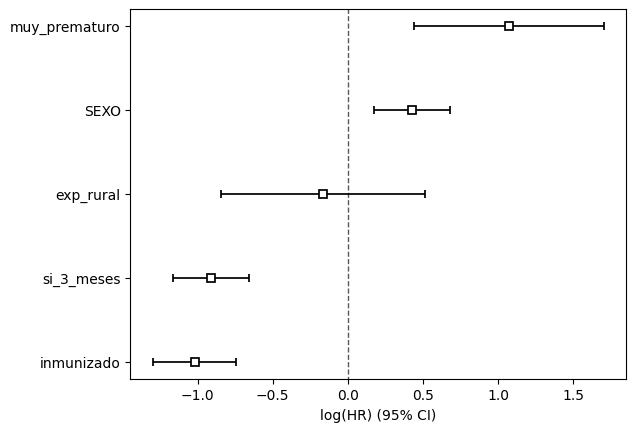

In [120]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(d[['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO', 'muy_prematuro', 'NOMBRE_REGION','exp_rural'#,'is_rural'
             ]], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop",strata=['NOMBRE_REGION'], show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

In [ ]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(d[['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO', 'muy_prematuro', 'categori_macro','is_rural']], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop",strata=['categori_macro','is_rural'], show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

In [161]:
bins = list(np.arange(0, 51, 5)) + [100]  

labels = [f"{i}-{i+5}" for i in range(0, 50, 5)] + ["50-100"]

de['age_mom_strata'] = pd.cut(de['EDAD_M'], bins=bins, labels=labels, right=False)

In [163]:
de['age_mom_strata'].value_counts()

age_mom_strata
30-35     70963
25-30     61695
35-40     45724
20-25     37421
40-45     12105
15-20      7937
45-50       811
10-15       224
50-100       36
0-5           0
5-10          0
Name: count, dtype: int64

In [ ]:
d['age_mom_strata'].value_counts()

In [ ]:
d[(d['EDAD_M']==99) & (d['event']==0) ]

In [ ]:
d[d['EDAD_M']>35]['EDAD_M'].value_counts(sort=True)

In [ ]:
d[d['EDAD_M']>34]['EDAD_M'].value_counts()

In [ ]:

ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(d[['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO', 'muy_prematuro', 'EDAD_M']], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

In [191]:
# d['inmu_time'] = d['inmunizado']*(d['stop']-d['start'])
# bins = list(np.arange(0, 64, 7))  + [float('inf')]
# labels = [f"{i}-{i+7}" for i in range(0, 63, 7)] + ['63+'] 
# d['inmu_time_groups'] = pd.cut(d['inmu_time'], bins=bins, labels=labels, right=False, ordered=True)
# d['inmu_time_strata'] = d['inmu_time_strata'].astype('category').cat.codes + 1

In [195]:
d['inmu_time'].describe()

count    237234.000000
mean         21.798056
std          27.014478
min           0.000000
25%           0.000000
50%           0.000000
75%          44.000000
max         116.000000
Name: inmu_time, dtype: float64

In [192]:
d['inmu_time_strata'].unique()

array([ 2,  5,  7, 11,  8,  4,  3,  9,  1,  6, 10], dtype=int8)

In [193]:
d['inmu_time_groups'].unique()

['0-7', '21-28', '35-42', '63+', '42-49', '14-21', '7-14', '49-56', '28-35', '56-63']
Categories (10, object): ['0-7' < '7-14' < '14-21' < '21-28' ... '42-49' < '49-56' < '56-63' < '63+']

In [194]:
d[['inmu_time_groups', 'inmu_time_strata']]

,inmu_time_groups,inmu_time_strata
0,0-7,2
1,21-28,5
2,35-42,7
3,0-7,2
4,0-7,2
...,...,...
237229,63+,1
237230,0-7,2
237231,28-35,6
237232,0-7,2


In [231]:
df_actual=d.copy()

In [232]:
df_inm_t = cov_inmune_d(df_actual, base, df_model,d=7)
df_inm_t14 = cov_inmune_d(df_inm_t, base, df_model,d=14)
df_inm_t21 = cov_inmune_d(df_inm_t14, base, df_model,d=21)
df_inm_t28 = cov_inmune_d(df_inm_t21, base, df_model,d=28)

In [237]:
def strats_inmu(row):
        inm_cols = ['inm_mayor_7d', 'inm_mayor_14d', 'inm_mayor_21d','inm_mayor_28d']
        
        if row[inm_cols[3]] == 1:
            strat_inmu = 3
        
        elif row[inm_cols[2]] == 1:
            strat_inmu = 2
            
        elif row[inm_cols[1]] == 1:
            strat_inmu = 1
            
        elif row[inm_cols[0]] == 1:
            strat_inmu = 0
        
        else:
            strat_inmu = -1

        return strat_inmu

In [238]:
df_inm_t28['strats_inmu'] = df_inm_t28.apply(strats_inmu, axis=1)

In [239]:
df_inm_t28.columns

Index(['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO',
       'muy_prematuro', 'EDAD_M', 'INS_C_M', 'COMUNA', 'COMUNA_N', 'REG_RES',
       'URBA_RURAL', 'Macrozona2', 'NOMBRE_REGION', 'categori_macro',
       'categori_regions', 'Porcentaje Urbano', 'porcent_rural', 'exp_rural',
       'duration', 'inm_mayor_7d', 'inm_mayor_14d', 'inm_mayor_21d',
       'inm_mayor_28d', 'strats_inmu'],
      dtype='object')

Iteration 1: norm_delta = 8.90e-01, step_size = 0.9500, log_lik = -3301.96518, newton_decrement = 8.19e+01, seconds_since_start = 1.0
Iteration 2: norm_delta = 9.52e-02, step_size = 0.9500, log_lik = -3228.29530, newton_decrement = 3.18e+00, seconds_since_start = 2.1
Iteration 3: norm_delta = 2.12e-02, step_size = 0.9500, log_lik = -3224.82713, newton_decrement = 1.97e-01, seconds_since_start = 3.2
Iteration 4: norm_delta = 2.94e-03, step_size = 1.0000, log_lik = -3224.62172, newton_decrement = 3.16e-03, seconds_since_start = 4.4
Iteration 5: norm_delta = 3.28e-05, step_size = 1.0000, log_lik = -3224.61854, newton_decrement = 3.90e-07, seconds_since_start = 5.5
Iteration 6: norm_delta = 4.10e-09, step_size = 1.0000, log_lik = -3224.61854, newton_decrement = 6.10e-15, seconds_since_start = 6.7
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 247254 periods, 148892 subjects, 304 events>
         event col = 'event'
            strata = strats_inmu
number of subjects = 148892
 number of periods = 247254
  number of events = 304
partial log-likelihood = -3224.62
  time fit was run = 2024-09-11 11:20:55 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -1.43      0.24      0.15           -1.73           -1.14                0.18                0.32
si_3_meses    -0.77      0.46      0.12           -1.01           -0.52                0.36                0.59
SEXO           0.42      1.53      0.12            0.19            0.66                1.21                1.93
muy_prematuro  1.03      2.81      0.31            0.43            1.64                1.54                5.13
exp_rural     -0.92      0.40      0.32           -1.55           -0.30                0.21                0.74

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -9.64 <0.005     70.61
si_3_meses       0.00 -6.17 <0.005     30.43
SEXO             0.00  3.61 <0.005     11.67
muy_prematuro    0.00  3.36 <0.005     10.31
exp_rural        0.00 -2.90 <0.005      8.07
---
Partial AIC = 6459.24
log-likelihood ratio test = 154.69 on 5 df
-log2(p) of ll-ratio test = 102.56

covariate
inmunizado       0.761615
si_3_meses       0.535472
SEXO            -0.529362
muy_prematuro   -1.809355
exp_rural        0.603010
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.821912         0.680903
si_3_meses            0.635915         0.407318
SEXO                 -0.214247        -0.926254
muy_prematuro        -0.537101        -4.134651
exp_rural             0.787289         0.259084


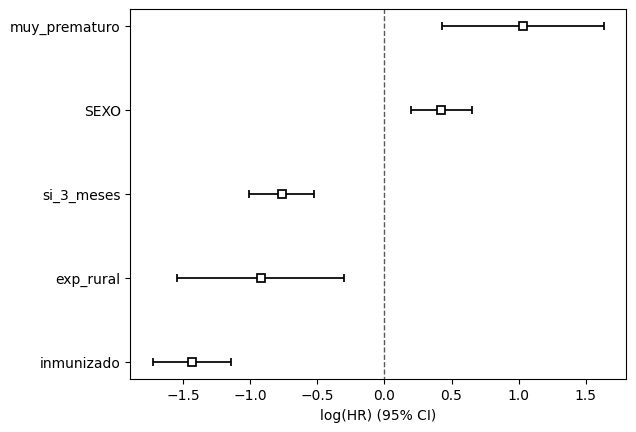

In [240]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_inm_t28[['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO', 'muy_prematuro','exp_rural','strats_inmu' #,'is_rural'
             ]], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop",strata=['strats_inmu',], show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

Iteration 1: norm_delta = 9.09e-01, step_size = 0.9500, log_lik = -2703.64063, newton_decrement = 8.07e+01, seconds_since_start = 0.8
Iteration 2: norm_delta = 8.11e-02, step_size = 0.9500, log_lik = -2631.95718, newton_decrement = 2.77e+00, seconds_since_start = 1.5
Iteration 3: norm_delta = 1.95e-02, step_size = 0.9500, log_lik = -2628.92719, newton_decrement = 1.77e-01, seconds_since_start = 2.3
Iteration 4: norm_delta = 2.71e-03, step_size = 1.0000, log_lik = -2628.74376, newton_decrement = 2.71e-03, seconds_since_start = 3.1
Iteration 5: norm_delta = 2.82e-05, step_size = 1.0000, log_lik = -2628.74103, newton_decrement = 2.88e-07, seconds_since_start = 4.0
Iteration 6: norm_delta = 3.03e-09, step_size = 1.0000, log_lik = -2628.74103, newton_decrement = 3.32e-15, seconds_since_start = 4.8
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 247254 periods, 148892 subjects, 304 events>
         event col = 'event'
            strata = ['NOMBRE_REGION', 'strats_inmu']
number of subjects = 148892
 number of periods = 247254
  number of events = 304
partial log-likelihood = -2628.74
  time fit was run = 2024-09-11 11:21:15 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -1.50      0.22      0.15           -1.80           -1.21                0.17                0.30
si_3_meses    -0.75      0.47      0.12           -1.00           -0.51                0.37                0.60
SEXO           0.42      1.53      0.12            0.19            0.65                1.21                1.92
muy_prematuro  0.98      2.67      0.31            0.38            1.59                1.46                4.88
exp_rural     -0.26      0.77      0.33           -0.91            0.39                0.40                1.47

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -9.98 <0.005     75.46
si_3_meses       0.00 -6.06 <0.005     29.46
SEXO             0.00  3.58 <0.005     11.53
muy_prematuro    0.00  3.18 <0.005      9.43
exp_rural        0.00 -0.79   0.43      1.22
---
Partial AIC = 5267.48
log-likelihood ratio test = 149.80 on 5 df
-log2(p) of ll-ratio test = 99.10

covariate
inmunizado       0.777536
si_3_meses       0.529527
SEXO            -0.525101
muy_prematuro   -1.667521
exp_rural        0.230410
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.834412         0.701125
si_3_meses            0.631338         0.399600
SEXO                 -0.210758        -0.921054
muy_prematuro        -0.458322        -3.879353
exp_rural             0.597891        -0.472905


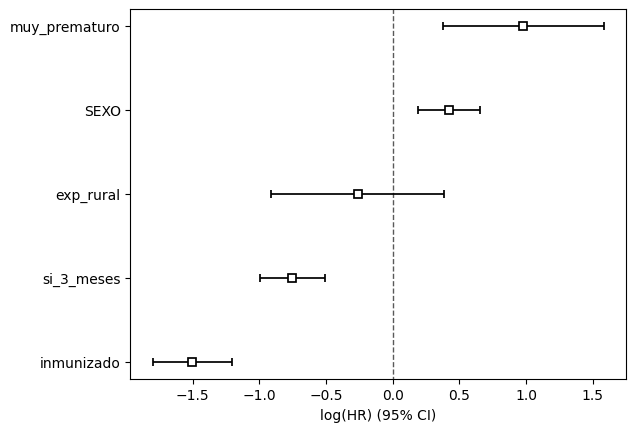

In [241]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_inm_t28[['start', 'inmunizado', 'stop', 'RUN', 'event', 'si_3_meses', 'SEXO', 'muy_prematuro', 'NOMBRE_REGION','exp_rural','strats_inmu' #,'is_rural'
             ]], 
          id_col="RUN", event_col="event", start_col="start", stop_col="stop",strata=['NOMBRE_REGION','strats_inmu'], show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

Iteration 1: norm_delta = 8.96e-01, step_size = 0.9500, log_lik = -1224.95621, newton_decrement = 3.51e+01, seconds_since_start = 0.5
Iteration 2: norm_delta = 8.32e-02, step_size = 0.9500, log_lik = -1191.14769, newton_decrement = 6.75e-01, seconds_since_start = 1.0
Iteration 3: norm_delta = 1.36e-02, step_size = 0.9500, log_lik = -1190.42919, newton_decrement = 2.49e-02, seconds_since_start = 1.6
Iteration 4: norm_delta = 1.38e-03, step_size = 1.0000, log_lik = -1190.40366, newton_decrement = 2.27e-04, seconds_since_start = 2.1
Iteration 5: norm_delta = 6.72e-06, step_size = 1.0000, log_lik = -1190.40343, newton_decrement = 5.52e-09, seconds_since_start = 2.6
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 185584 periods, 85014 subjects, 109 events>
         event col = 'event'
number of subjects = 85014
 number of periods = 185584
  number of events = 109
partial log-likelihood = -1190.40
  time fit was run = 2024-08-27 23:17:48 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -1.40      0.25      0.27           -1.93           -0.87                0.14                0.42
si_3_meses    -1.17      0.31      0.22           -1.60           -0.74                0.20                0.47
inm_mayor_7d   0.13      1.14      0.33           -0.51            0.78                0.60                2.17
SEXO           0.44      1.55      0.20            0.06            0.83                1.06                2.29
muy_prematuro  0.98      2.68      0.51           -0.02            1.98                0.98                7.27

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -5.14 <0.005     21.78
si_3_meses       0.00 -5.38 <0.005     23.64
inm_mayor_7d     0.00  0.40   0.69      0.54
SEXO             0.00  2.24   0.02      5.32
muy_prematuro    0.00  1.93   0.05      4.22
---
Partial AIC = 2390.81
log-likelihood ratio test = 69.11 on 5 df
-log2(p) of ll-ratio test = 42.53

covariate
inmunizado       0.753104
si_3_meses       0.690246
inm_mayor_7d    -0.141623
SEXO            -0.554908
muy_prematuro   -1.676611
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.855205         0.579007
si_3_meses            0.797959         0.525109
inm_mayor_7d          0.400175        -1.172805
SEXO                 -0.057121        -1.287096
muy_prematuro         0.015205        -6.274862


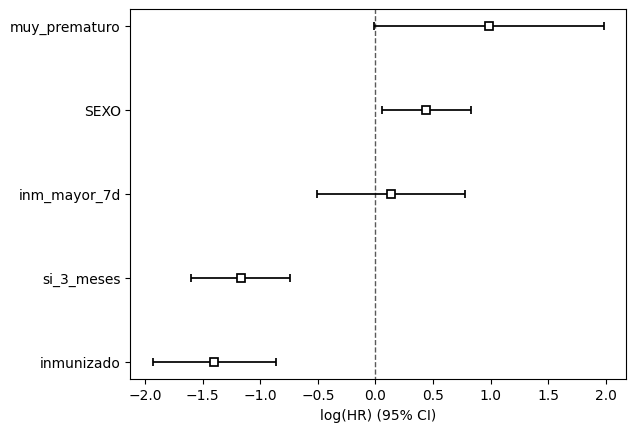

In [13]:
df_t7 = df_inm_t.merge(covs[2], on='RUN',how='left') 
cox_model(df_t7)

In [ ]:
df_t14 = df_inm_t14.merge(covs[2], on='RUN',how='left') 
cox_model(df_t14)

Iteration 1: norm_delta = 8.94e-01, step_size = 0.9500, log_lik = -1224.95621, newton_decrement = 3.52e+01, seconds_since_start = 0.6
Iteration 2: norm_delta = 8.83e-02, step_size = 0.9500, log_lik = -1191.01460, newton_decrement = 7.11e-01, seconds_since_start = 1.3
Iteration 3: norm_delta = 2.74e-02, step_size = 0.9500, log_lik = -1190.25700, newton_decrement = 3.14e-02, seconds_since_start = 2.0
Iteration 4: norm_delta = 2.48e-02, step_size = 1.0000, log_lik = -1190.22360, newton_decrement = 2.67e-03, seconds_since_start = 2.6
Iteration 5: norm_delta = 2.48e-02, step_size = 1.0000, log_lik = -1190.22028, newton_decrement = 8.98e-04, seconds_since_start = 3.2
Iteration 6: norm_delta = 2.48e-02, step_size = 1.0000, log_lik = -1190.21915, newton_decrement = 3.30e-04, seconds_since_start = 3.9
Iteration 7: norm_delta = 2.48e-02, step_size = 1.0000, log_lik = -1190.21873, newton_decrement = 1.22e-04, seconds_since_start = 4.5
Iteration 8: norm_delta = 2.48e-02, step_size = 1.0000, log_li

<lifelines.CoxTimeVaryingFitter: fitted with 196885 periods, 85014 subjects, 109 events>
         event col = 'event'
number of subjects = 85014
 number of periods = 196885
  number of events = 109
partial log-likelihood = -1190.22
  time fit was run = 2024-08-27 23:02:06 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
inmunizado     -1.40      0.25      0.27           -1.93           -0.86                0.14                0.42
si_3_meses     -1.17      0.31      0.22           -1.60           -0.74                0.20                0.47
inm_mayor_7d    0.06      1.06      0.40           -0.73            0.84                0.48                2.32
inm_mayor_14d   0.19      1.21      0.49           -0.77            1.14                0.46                3.13
inm_mayor_21d -17.15      0.00   9301.52       -18247.80        18213.49                0.00                 inf
inm_mayor_28d   0.03      1.03  80947.29      -158653.75       158653.81                0.00                 inf
SEXO            0.44      1.55      0.20            0.06            0.83                1.06                2.29
muy_prematuro   0.98      2.66      0.51           -0.02            1.98                0.98                7.24

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -5.13 <0.005     21.73
si_3_meses       0.00 -5.38 <0.005     23.65
inm_mayor_7d     0.00  0.14   0.89      0.17
inm_mayor_14d    0.00  0.39   0.70      0.51
inm_mayor_21d    0.00 -0.00   1.00      0.00
inm_mayor_28d    0.00  0.00   1.00      0.00
SEXO             0.00  2.24   0.03      5.32
muy_prematuro    0.00  1.92   0.05      4.18
---
Partial AIC = 2396.44
log-likelihood ratio test = 69.48 on 8 df
-log2(p) of ll-ratio test = 37.22

covariate
inmunizado       0.752799
si_3_meses       0.690323
inm_mayor_7d    -0.056652
inm_mayor_14d   -0.206335
inm_mayor_21d    1.000000
inm_mayor_28d   -0.028418
SEXO            -0.554644
muy_prematuro   -1.662765
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.855048         0.578424
si_3_meses            0.798013         0.525219
inm_mayor_7d          0.517873        -1.315808
inm_mayor_14d         0.535388        -2.132174
inm_mayor_21d         1.000000             -inf
inm_mayor_28d         1.000000             -inf
SEXO                 -0.056935        -1.286723
muy_prematuro         0.020684        -6.240074


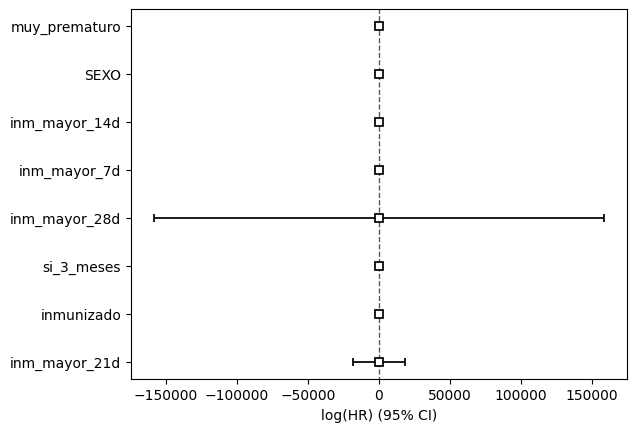

In [10]:
df_temp = df_inm_t28.merge(covs[2], on='RUN',how='left') 
cox_model(df_temp)

#### Into CSV

In [ ]:
# Lista para almacenar los resultados
resultados = []

# Loop para iterar sobre las covariables y calcular los modelos Cox
for i in covs:
    # Realiza el merge
    d = df_01.merge(i, on='RUN', how='left')
    
    # Ajusta el modelo Cox
    ctv_01 = CoxTimeVaryingFitter()
    ctv_01.fit(d, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
    
    # Obtén los coeficientes y los intervalos de confianza
    coef_01 = ctv_01.params_
    conf_01 = ctv_01.confidence_intervals_
    
    # Calcula los Hazard Ratios
    hazard_ratios_01 = 1 - np.exp(coef_01)
    hazard_ratios_conf_int_01 = 1 - np.exp(conf_01)
    
    # Almacena los resultados en la lista
    for var in coef_01.index:
        resultados.append({
            'Modelo': ', '.join(i),
            'Variable': var,
            'Coeficiente': coef_01[var],
            'IC_coef': conf_01[var],
            'HR': hazard_ratios_01[var],
            'IC_HR 95%': f"[{hazard_ratios_conf_int_01.loc[var, 0.025]:.2f}, {hazard_ratios_conf_int_01.loc[var, 0.975]:.2f}]"
        })

# Crea un DataFrame a partir de los resultados
df_resultados = pd.DataFrame(resultados)

# Exporta el DataFrame a un archivo CSV
df_resultados.to_csv('resultados_cox.csv', index=False)

print("Resultados guardados en 'resultados_cox.csv'.")

## Modelo UPC

### Preprocesamiento

In [4]:
df_f=dfs[26]
df_upc, base_upc, df_model_upc, covs = preprocess_model_upc(df_f)

### Modelo_UPC_0

Iteration 1: norm_delta = 8.90e-01, step_size = 0.9500, log_lik = -493.27409, newton_decrement = 1.21e+01, seconds_since_start = 0.2
Iteration 2: norm_delta = 1.06e-01, step_size = 0.9500, log_lik = -482.97755, newton_decrement = 2.12e-01, seconds_since_start = 0.3
Iteration 3: norm_delta = 3.53e-03, step_size = 0.9500, log_lik = -482.76860, newton_decrement = 2.43e-04, seconds_since_start = 0.5
Iteration 4: norm_delta = 1.84e-04, step_size = 1.0000, log_lik = -482.76836, newton_decrement = 5.99e-07, seconds_since_start = 0.7
Iteration 5: norm_delta = 3.32e-09, step_size = 1.0000, log_lik = -482.76836, newton_decrement = 1.94e-16, seconds_since_start = 0.9
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 195808 periods, 108480 subjects, 43 events>
         event col = 'event'
number of subjects = 108480
 number of periods = 195808
  number of events = 43
partial log-likelihood = -482.77
  time fit was run = 2024-09-02 18:48:05 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -1.56      0.21      0.34           -2.22           -0.90                0.11                0.41

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -4.63 <0.005     18.05
---
Partial AIC = 967.54
log-likelihood ratio test = 21.01 on 1 df
-log2(p) of ll-ratio test = 17.74

covariate
inmunizado    0.789938
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.891521         0.593231


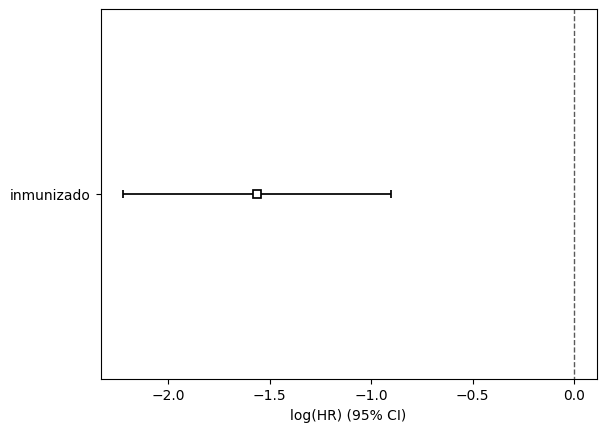

In [5]:
cox_model(df_upc)

### Modelo_UPC_0 + covariables fijas

Iteration 1: norm_delta = 1.76e+00, step_size = 0.9500, log_lik = -2639.05319, newton_decrement = 1.73e+02, seconds_since_start = 0.3
Iteration 2: norm_delta = 8.67e-01, step_size = 0.9500, log_lik = -2572.37363, newton_decrement = 5.86e+01, seconds_since_start = 0.7
Iteration 3: norm_delta = 1.79e-01, step_size = 0.9500, log_lik = -2528.79904, newton_decrement = 3.88e+00, seconds_since_start = 1.0
Iteration 4: norm_delta = 6.88e-03, step_size = 1.0000, log_lik = -2524.96279, newton_decrement = 6.28e-03, seconds_since_start = 1.3
Iteration 5: norm_delta = 2.12e-05, step_size = 1.0000, log_lik = -2524.95650, newton_decrement = 1.34e-07, seconds_since_start = 1.7
Iteration 6: norm_delta = 1.72e-09, step_size = 1.0000, log_lik = -2524.95650, newton_decrement = 8.84e-16, seconds_since_start = 2.0
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 196734 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 196734
  number of events = 228
partial log-likelihood = -2524.96
  time fit was run = 2024-08-27 16:01:39 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -2.12      0.12      0.14           -2.39           -1.85                0.09                0.16
SEXO           0.34      1.41      0.13            0.08            0.61                1.08                1.84
muy_prematuro  1.22      3.38      0.34            0.55            1.88                1.73                6.58

               cmp to      z      p  -log2(p)
covariate                                    
inmunizado       0.00 -15.58 <0.005    179.36
SEXO             0.00   2.55   0.01      6.56
muy_prematuro    0.00   3.57 <0.005     11.47
---
Partial AIC = 5055.91
log-likelihood ratio test = 228.19 on 3 df
-log2(p) of ll-ratio test = 161.01

covariate
inmunizado       0.879918
SEXO            -0.411067
muy_prematuro   -2.375054
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.908025         0.843221
SEXO                 -0.083493        -0.837677
muy_prematuro        -0.731668        -5.578046


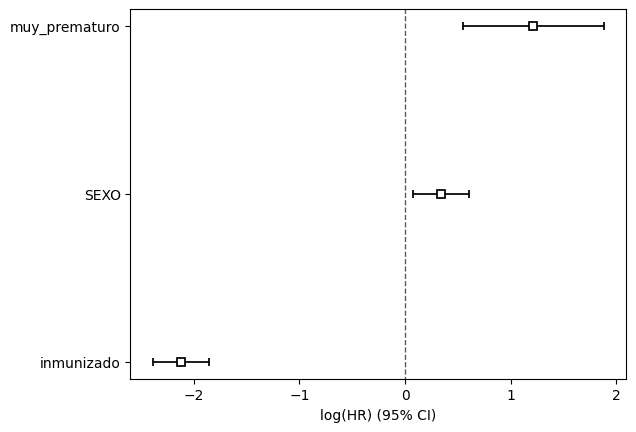

In [7]:
d=df_upc.merge(covs[2], on='RUN',how='left') 
cox_model(d)

### Modelo_UPC_3m

Iteration 1: norm_delta = 1.80e+00, step_size = 0.9500, log_lik = -2639.05319, newton_decrement = 1.76e+02, seconds_since_start = 0.3
Iteration 2: norm_delta = 8.76e-01, step_size = 0.9500, log_lik = -2565.88842, newton_decrement = 5.86e+01, seconds_since_start = 0.6
Iteration 3: norm_delta = 1.90e-01, step_size = 0.9500, log_lik = -2523.54356, newton_decrement = 4.22e+00, seconds_since_start = 0.9
Iteration 4: norm_delta = 6.61e-03, step_size = 1.0000, log_lik = -2519.38098, newton_decrement = 4.73e-03, seconds_since_start = 1.2
Iteration 5: norm_delta = 1.33e-06, step_size = 1.0000, log_lik = -2519.37625, newton_decrement = 1.93e-10, seconds_since_start = 1.5
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 205106 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205106
  number of events = 228
partial log-likelihood = -2519.38
  time fit was run = 2024-08-27 16:04:51 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -2.18      0.11      0.14           -2.45           -1.91                0.09                0.15
si_3_meses -0.72      0.49      0.14           -1.00           -0.44                0.37                0.64

            cmp to      z      p  -log2(p)
covariate                                 
inmunizado    0.00 -15.97 <0.005    188.28
si_3_meses    0.00  -5.02 <0.005     20.86
---
Partial AIC = 5042.75
log-likelihood ratio test = 239.35 on 2 df
-log2(p) of ll-ratio test = 172.66

covariate
inmunizado    0.887039
si_3_meses    0.514125
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.913565         0.852372
si_3_meses         0.633511         0.355850


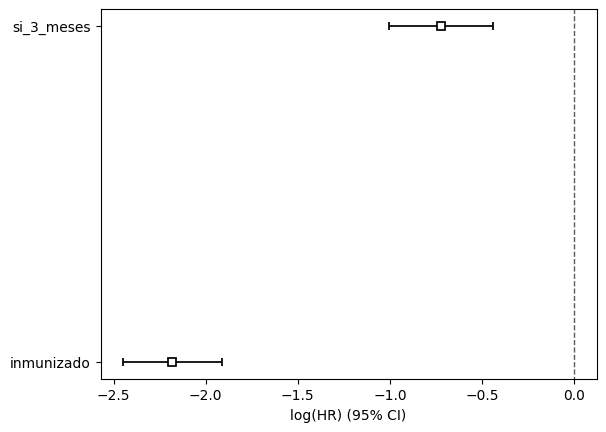

In [8]:
df_upc3m = cov_3meses(df_upc, base_upc, df_model_upc)
cox_model(df_upc3m)

### Modelo_UPC_3m + covariables fijas

Iteration 1: norm_delta = 1.81e+00, step_size = 0.9500, log_lik = -2639.05319, newton_decrement = 1.78e+02, seconds_since_start = 0.3
Iteration 2: norm_delta = 8.76e-01, step_size = 0.9500, log_lik = -2563.93852, newton_decrement = 5.86e+01, seconds_since_start = 0.7
Iteration 3: norm_delta = 1.90e-01, step_size = 0.9500, log_lik = -2521.58735, newton_decrement = 4.22e+00, seconds_since_start = 1.0
Iteration 4: norm_delta = 6.61e-03, step_size = 1.0000, log_lik = -2517.42366, newton_decrement = 4.73e-03, seconds_since_start = 1.4
Iteration 5: norm_delta = 1.33e-06, step_size = 1.0000, log_lik = -2517.41893, newton_decrement = 1.94e-10, seconds_since_start = 1.7
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 205106 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205106
  number of events = 228
partial log-likelihood = -2517.42
  time fit was run = 2024-08-27 16:04:53 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -2.19      0.11      0.14           -2.46           -1.92                0.09                0.15
si_3_meses -0.72      0.49      0.14           -1.00           -0.43                0.37                0.65
prematuro   0.41      1.50      0.20            0.02            0.79                1.02                2.21

            cmp to      z      p  -log2(p)
covariate                                 
inmunizado    0.00 -16.02 <0.005    189.45
si_3_meses    0.00  -4.98 <0.005     20.60
prematuro     0.00   2.08   0.04      4.74
---
Partial AIC = 5040.84
log-likelihood ratio test = 243.27 on 3 df
-log2(p) of ll-ratio test = 171.84

covariate
inmunizado    0.887877
si_3_meses    0.511702
prematuro    -0.503565
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.914212         0.853458
si_3_meses         0.631681         0.352640
prematuro         -0.023847        -1.208051
Iteration 1: norm_delta = 1.82e+00, step_size = 0.9500, log_lik = -2639.05319, newton_decrement = 1.83e+02, seconds_since_start = 0.4
Iteration 2: norm_delta = 8.74e-01, step_size = 0.9500, log_lik = -2563.51806, newton_decrement = 6.02e+01, seconds_since_start = 0.7
Iteration 3: norm_delta = 1.86e-01, step_size = 0.9500, log_lik = -2518.91501, newton_decrement = 4.20e+00, seconds_since_start = 1.1
Iteration 4: norm_delta = 7.18e-03, step_size = 1.0000, log_lik = -2514.76806, newton_decrement = 7.46e-03, seconds_since_start = 1.4
Iteration 5: norm_delta = 3.56e-05, step_size = 1.0000, log_lik = -2514.76058, newton_decrement = 3.80e-07, seconds_since_start = 1.8
Iteration 6

<lifelines.CoxTimeVaryingFitter: fitted with 205106 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205106
  number of events = 228
partial log-likelihood = -2514.76
  time fit was run = 2024-08-27 16:04:56 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
inmunizado         -2.19      0.11      0.14           -2.46           -1.92                0.09                0.15
si_3_meses         -0.72      0.49      0.14           -1.00           -0.43                0.37                0.65
muy_prematuro       1.21      3.35      0.34            0.54            1.88                1.72                6.54
prematuro_moderado  0.16      1.18      0.24           -0.31            0.63                0.73                1.88

                    cmp to      z      p  -log2(p)
covariate                                         
inmunizado            0.00 -16.04 <0.005    189.89
si_3_meses            0.00  -4.98 <0.005     20.56
muy_prematuro         0.00   3.55 <0.005     11.33
prematuro_moderado    0.00   0.68   0.50      1.00
---
Partial AIC = 5037.52
log-likelihood ratio test = 248.59 on 4 df
-log2(p) of ll-ratio test = 172.35

covariate
inmunizado            0.888265
si_3_meses            0.511212
muy_prematuro        -2.352507
prematuro_moderado   -0.176324
dtype: float64
                    95% lower-bound  95% upper-bound
covariate                                           
inmunizado                 0.914519         0.853949
si_3_meses                 0.631287         0.352033
muy_prematuro             -0.718422        -5.540482
prematuro_moderado         0.265452        -0.883795
Iteration 1: norm_delta = 1.83e+00, step_size = 0.9500, log_lik = -2639.05319, newton_decrement = 1.86e+02, seconds_since_start = 0.4
Iteration 2: norm_delta = 8.75e-01, step_size = 0.9500, log_lik = -2560.39138, newton_decrement = 6.02e+01, seconds_since_start = 0.7
Iteration 3: norm_delta = 1.86e-01, step_size = 0.9500, log_lik = -2515.79192, newton_decrement = 4.20e+00, seconds_since_start = 1.1
Iteration 4: norm_delta = 7.17e-03, step_size = 1.0000, log_lik = -2511.64201, newton_decrement = 7.41e-03, seconds_since_start = 1

...

covariate
inmunizado       0.887932
si_3_meses       0.511677
SEXO            -0.413042
muy_prematuro   -2.253157
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.914244         0.853546
si_3_meses            0.631637         0.352651
SEXO                 -0.084994        -0.840274
muy_prematuro        -0.669421        -5.339340
Iteration 1: norm_delta = 1.83e+00, step_size = 0.9500, log_lik = -2639.05319, newton_decrement = 1.86e+02, seconds_since_start = 0.4
Iteration 2: norm_delta = 8.74e-01, step_size = 0.9500, log_lik = -2560.18872, newton_decrement = 6.02e+01, seconds_since_start = 0.8
Iteration 3: norm_delta = 1.86e-01, step_size = 0.9500, log_lik = -2515.59414, newton_decrement = 4.19e+00, seconds_since_start = 1.2
Iteration 4: norm_delta = 7.17e-03, step_size = 1.0000, log_lik = -2511.44998, newton_decrement = 7.41e-03, seconds_since_start = 1.6
Iteration 5: norm_delta = 3.49e-05, step_size =

<lifelines.CoxTimeVaryingFitter: fitted with 205106 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205106
  number of events = 228
partial log-likelihood = -2511.44
  time fit was run = 2024-08-27 16:05:01 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
inmunizado         -2.19      0.11      0.14           -2.46           -1.92                0.09                0.15
si_3_meses         -0.72      0.49      0.14           -1.00           -0.43                0.37                0.65
SEXO                0.34      1.41      0.13            0.08            0.61                1.08                1.84
muy_prematuro       1.19      3.29      0.34            0.52            1.86                1.69                6.43
prematuro_moderado  0.15      1.16      0.24           -0.32            0.62                0.73                1.86

                    cmp to      z      p  -log2(p)
covariate                                         
inmunizado            0.00 -16.04 <0.005    189.93
si_3_meses            0.00  -4.98 <0.005     20.60
SEXO                  0.00   2.56   0.01      6.56
muy_prematuro         0.00   3.50 <0.005     11.05
prematuro_moderado    0.00   0.63   0.53      0.92
---
Partial AIC = 5032.89
log-likelihood ratio test = 255.22 on 5 df
-log2(p) of ll-ratio test = 174.00

covariate
inmunizado            0.888300
si_3_meses            0.511583
SEXO                 -0.411183
muy_prematuro        -2.294485
prematuro_moderado   -0.164222
dtype: float64
                    95% lower-bound  95% upper-bound
covariate                                           
inmunizado                 0.914545         0.853994
si_3_meses                 0.631566         0.352525
SEXO                      -0.083529        -0.837918
muy_prematuro             -0.688423        -5.428263
prematuro_moderado         0.273077        -0.864589
Iteration 1: norm_delta = 1.82e+00, step_size = 0.9500, log_lik = -2639.05319, newton_decrement = 1.86e+02, seconds_since_start = 0.4
Iteration 2: norm_delta = 8.72e-01, step_size = 0.9500, log_lik = -2562.14424, newton_decrement = 6.14e+01, seconds_since_start = 0.8
Iteration 3: norm_delta = 1.84e-01, step_size = 0.9500, log_lik = -2516.00187, newton_decrement = 4.39e+00, seconds_since_start = 1.2
Iteration 4: norm_delta = 9.05e-03, step_size =

<lifelines.CoxTimeVaryingFitter: fitted with 205106 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205106
  number of events = 228
partial log-likelihood = -2511.62
  time fit was run = 2024-08-27 16:05:04 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -2.19      0.11      0.14           -2.46           -1.92                0.09                0.15
si_3_meses    -0.72      0.49      0.14           -1.00           -0.43                0.37                0.65
SEXO           0.34      1.41      0.14            0.07            0.61                1.07                1.84
muy_prematuro  1.09      2.98      0.59           -0.06            2.24                0.94                9.42
sex*prem       0.13      1.14      0.72           -1.28            1.55                0.28                4.70

               cmp to      z      p  -log2(p)
covariate                                    
inmunizado       0.00 -16.03 <0.005    189.70
si_3_meses       0.00  -4.98 <0.005     20.60
SEXO             0.00   2.48   0.01      6.25
muy_prematuro    0.00   1.86   0.06      3.99
sex*prem         0.00   0.19   0.85      0.23
---
Partial AIC = 5033.23
log-likelihood ratio test = 254.87 on 5 df
-log2(p) of ll-ratio test = 173.76

covariate
inmunizado       0.887934
si_3_meses       0.511564
SEXO            -0.405990
muy_prematuro   -1.980274
sex*prem        -0.144381
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.914246         0.853550
si_3_meses            0.631555         0.352495
SEXO                 -0.074175        -0.840303
muy_prematuro         0.056768        -8.416594
sex*prem              0.721127        -3.696078


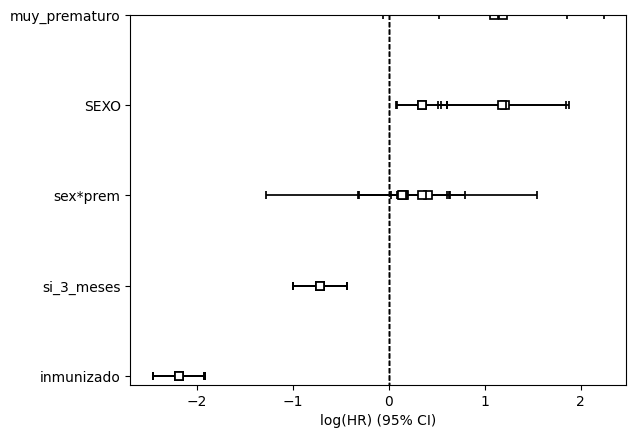

In [9]:
for i in covs:
    d=df_upc3m.merge(i, on='RUN',how='left') 
    cox_model(d)

## Kaplan Mayer

In [ ]:
from lifelines import KaplanMeierFitter
# Supongamos que tienes un DataFrame `d` con columnas 'duracion' y 'evento'
# 'duracion': Tiempo hasta el evento o censura
# 'evento': 1 si el evento ocurrió, 0 si está censurado

# Crea el objeto KaplanMeierFitter
kmf = KaplanMeierFitter()

kmf.fit(d['duration'], event_observed=d['event'])

# Graficar la curva de supervivencia
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Curva de Supervivencia Kaplan-Meier')
plt.xlabel('Tiempo')
plt.ylabel('Probabilidad de Supervivencia')
plt.grid(True)
plt.show()


In [ ]:
# Crea el objeto KaplanMeierFitter
kmf = KaplanMeierFitter()

# Lista de regiones para graficar
inmunizados = d['inmunizado'].unique()

# Configura la gráfica
plt.figure(figsize=(12, 8))

# Ajusta el modelo y grafica para cada región
for i in inmunizados:
    mask = (d['inmunizado'] == i)
    kmf.fit(d['duration'][mask], event_observed=d['event'][mask], label=i)
    kmf.plot_survival_function()

plt.title('Curvas de Supervivencia Kaplan-Meier por inmunización')
plt.xlabel('Tiempo')
plt.ylabel('Probabilidad de Supervivencia')
plt.legend(title='Inmunizado')
plt.grid(True)
plt.show()


In [ ]:
# Regiones específicas para las que deseas graficar las curvas
regiones_especificas = ['COQUIMBO']

# Crea el objeto KaplanMeierFitter
kmf = KaplanMeierFitter()

# Configura la gráfica
plt.figure(figsize=(14, 10))

# Itera sobre cada región específica
for region in regiones_especificas:
    # Filtra los datos para la región actual
    mask_region = (d['NOMBRE_REGION'] == region)
    data_region = d[mask_region]
    
    # Lista de estados de inmunización para graficar
    inmunizados = data_region['inmunizado'].unique()
    
    # Itera sobre cada grupo de inmunización dentro de la región
    for inmunizado in inmunizados:
        mask_inmunizado = (data_region['inmunizado'] == inmunizado)
        kmf.fit(data_region['duration'][mask_inmunizado], event_observed=data_region['event'][mask_inmunizado], label=f'{region} - Inmunizado {inmunizado}')
        kmf.plot_survival_function()

plt.title('Curvas de Supervivencia Kaplan-Meier para Regiones Específicas')
plt.xlabel('Tiempo')
plt.ylabel('Probabilidad de Supervivencia')
plt.legend(title='Región - Inmunización', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

